# Entanglement, Bell States & Quantum Teleportation

Author: Vanessa Knight

## Objective

This notebook introduces multi-qubit quantum systems and one of the most fascinating phenomena in quantum computing: **entanglement**.

We will learn how to combine qubits, create Bell States, understand quantum teleportation, and see how classical and quantum information work together.

## Topics Covered

- Multi-Qubit Systems
- Tensor Products
- Controlled Gates
- CNOT Gate
- Bell States
- Entanglement
- Statevectors of Bell States
- Quantum Teleportation
- Quantum Measurements
- Classical Communication

## Learning Goals

By the end of this notebook, I should be able to:

- Explain what entanglement is.
- Create Bell States in Qiskit.
- Explain the purpose of the CNOT gate.
- Understand why quantum teleportation requires three qubits.
- Distinguish between quantum information and classical information.
- Explain why teleportation does **not** transmit information faster than light.

> This notebook builds directly upon the concepts of superposition, measurement, and quantum gates introduced in **Notebook 1**.

# 1. Multi-Qubit Systems

So far we have worked with only a single qubit.

Real quantum algorithms almost always require **multiple qubits** working together.

Adding another qubit dramatically increases the amount of information that can be represented.

For example,

| Number of Qubits | Basis States |
|-----------------|--------------|
| 1 | 2 |
| 2 | 4 |
| 3 | 8 |
| 4 | 16 |

In general,

$$
2^n
$$

possible computational basis states exist for **n** qubits.

Unlike classical bits, these basis states can all participate in quantum superposition.

## Tensor Products

When multiple qubits are combined, their joint quantum state is formed using the **tensor product**.

Examples:

$$
|0\rangle \otimes |0\rangle = |00\rangle
$$

$$
|0\rangle \otimes |1\rangle = |01\rangle
$$

$$
|1\rangle \otimes |0\rangle = |10\rangle
$$

$$
|1\rangle \otimes |1\rangle = |11\rangle
$$

These four basis states form the computational basis for a two-qubit quantum system.

> **Intuition:** Think of the tensor product as combining the state of each individual qubit into one larger quantum state describing the entire system.

## Tensor Products

When multiple qubits are combined, their joint quantum state is formed using the **tensor product**.

Examples:

$$
|0\rangle \otimes |0\rangle = |00\rangle
$$

$$
|0\rangle \otimes |1\rangle = |01\rangle
$$

$$
|1\rangle \otimes |0\rangle = |10\rangle
$$

$$
|1\rangle \otimes |1\rangle = |11\rangle
$$

These four basis states form the computational basis for a two-qubit quantum system.

> **Intuition:** Think of the tensor product as combining the state of each individual qubit into one larger quantum state describing the entire system.

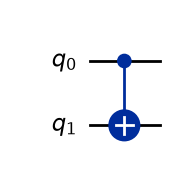

In [27]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)

# Apply CNOT
qc.cx(0, 1)

qc.draw("mpl")

### Notes

Suppose the initial state is

$$
|10\rangle
$$

The control qubit is

$$
|1\rangle
$$

so the target flips:

$$
|10\rangle
\rightarrow
|11\rangle
$$

Now suppose the initial state is

$$
|00\rangle
$$

The control qubit is

$$
|0\rangle
$$

so nothing changes:

$$
|00\rangle
\rightarrow
|00\rangle
$$

> **Important:** A CNOT gate by itself does **not** automatically create entanglement.

Entanglement occurs when the **control qubit is first placed into superposition**, usually by applying a Hadamard gate before the CNOT.

# 3. Bell States

A **Bell State** is the simplest example of **quantum entanglement**.

It is created by combining:

1. A **Hadamard gate** (creates superposition)
2. A **CNOT gate** (correlates the two qubits)

The result is a quantum state that cannot be separated into two independent qubits.

Instead, the two qubits become one shared quantum system.

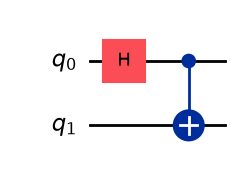

In [28]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)

# Step 1: Put qubit 0 into superposition
qc.h(0)

# Step 2: Entangle qubit 0 with qubit 1
qc.cx(0, 1)

qc.draw("mpl")

## How the Bell State is Created

The circuit begins in the state

$$
|00\rangle
$$

### Step 1 — Apply a Hadamard Gate

Applying

```python
qc.h(0)
```

creates

$$
\frac{|00\rangle+|10\rangle}{\sqrt2}
$$

The first qubit is now in superposition.

### Step 2 — Apply the CNOT Gate

Applying

```python
qc.cx(0,1)
```

acts on **each branch** of the superposition independently.

The CNOT transforms

$$
|00\rangle
\rightarrow
|00\rangle
$$

because the control qubit is 0.

It also transforms

$$
|10\rangle
\rightarrow
|11\rangle
$$

because the control qubit is 1.

The final Bell State becomes

$$
\frac{|00\rangle+|11\rangle}{\sqrt2}
$$

In [29]:
from qiskit.quantum_info import Statevector

state = Statevector.from_instruction(qc)

print(state)

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


## Understanding Entanglement

The Bell State

$$
\frac{|00\rangle+|11\rangle}{\sqrt2}
$$

cannot be separated into two independent qubits.

Instead,

- measuring the first qubit immediately determines the second,
- even though neither qubit had a definite value beforehand.

Possible measurements are

```text
00

or

11
```

You will **never** observe

```text
01

or

10
```

This perfect correlation is called **quantum entanglement**.

### Important

Entanglement does **not** mean information travels faster than light.

Each measurement is still random.

The remarkable feature is that **once one qubit is measured, the two outcomes are perfectly correlated.**

# 4. Measuring a Bell State

Although the Bell State is a quantum superposition, measurement always produces a **classical result**.

For the Bell State

$$
\frac{|00\rangle+|11\rangle}{\sqrt2}
$$

the only possible measurement outcomes are

```text
00

or

11
```

Each occurs with approximately **50% probability**.

The outcomes

```text
01

10
```

should never appear on an ideal simulator because the two qubits are perfectly entangled.

{'00': 507, '11': 493}


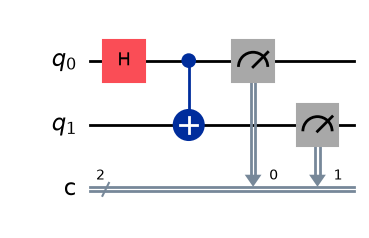

In [30]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

qc = QuantumCircuit(2, 2)

# Create Bell State
qc.h(0)
qc.cx(0, 1)

# Measure both qubits
qc.measure([0, 1], [0, 1])

backend = AerSimulator()

job = backend.run(qc, shots=1000)

result = job.result()

counts = result.get_counts()

print(counts)

qc.draw("mpl")

## Expected Result

A typical result might look like

```text
{'00': 503,
 '11': 497}
```

Notice that

```text
01
```

and

```text
10
```

never appear.

This demonstrates that the two qubits are **perfectly correlated**.

If the first qubit is measured as

```text
0
```

the second is always

```text
0
```

If the first qubit is measured as

```text
1
```

the second is always

```text
1
```

The individual measurements are random, but the relationship between them is perfectly correlated.

### Notes

It is important to distinguish between **correlation** and **entanglement**.

Two classical coins could also be perfectly correlated if they were prepared that way.

What makes a Bell State special is that the qubits do **not** possess definite values before measurement.

Instead, the two-qubit system exists in a shared quantum state until a measurement is performed.

This distinction is what makes quantum entanglement fundamentally different from classical correlation.

# 5. Quantum Teleportation

Quantum Teleportation allows the quantum state of one qubit to be transferred to another distant qubit **without physically sending the qubit itself**.

It does **not** teleport matter or energy.

Instead, it transfers the **quantum state**.

Quantum teleportation requires three ingredients:

- An unknown quantum state.
- A shared Bell pair (entanglement).
- Two bits of classical communication.

The original quantum state is destroyed during the teleportation process, so no quantum information is copied.

This is consistent with the **No-Cloning Theorem**, which states that an unknown quantum state cannot be copied perfectly.

## The Three Qubits

Quantum teleportation uses **three qubits**.

| Qubit | Purpose |
|-------|---------|
| q0 | Alice's unknown quantum state |
| q1 | Alice's half of the Bell pair |
| q2 | Bob's half of the Bell pair |

Initially,

- q0 contains the state we want to teleport.
- q1 and q2 are first entangled to create a Bell pair.
- Bob's qubit (q2) does **not** yet contain the teleported state.

The Bell pair must be created **before** Alice interacts with her unknown qubit.

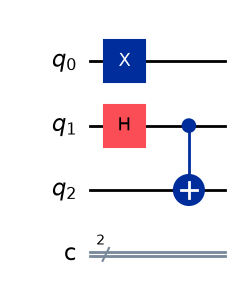

In [31]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(3, 2)

# Example state to teleport
qc.x(0)

# Create Bell pair between Alice and Bob
qc.h(1)
qc.cx(1, 2)

qc.draw("mpl")

## Why Create the Bell Pair First?

One of the most common questions is:

> Why don't we entangle Alice's unknown qubit first?

The answer is that the Bell pair acts as the **quantum communication channel** between Alice and Bob.

The teleportation protocol works in two stages:

### Stage 1

Create entanglement between

- Alice's Bell qubit (q1)
- Bob's qubit (q2)

using

```python
qc.h(1)
qc.cx(1,2)
```

### Stage 2

Mix Alice's unknown state (q0) into the Bell pair.

This allows the information contained in q0 to be transferred to Bob after measurement and classical communication.

The Bell pair must already exist before the teleportation protocol can begin.

# 6. Alice Encodes Her Quantum State

Once the Bell pair has been created, Alice combines her unknown qubit with her half of the Bell pair.

This is done using two operations:

```python
qc.cx(0,1)
qc.h(0)
```

These two gates transform Alice's quantum state into information that can later be transmitted using **two classical bits**.

Notice that the Bell pair has already been created before these operations occur.

This order is essential for the teleportation protocol.

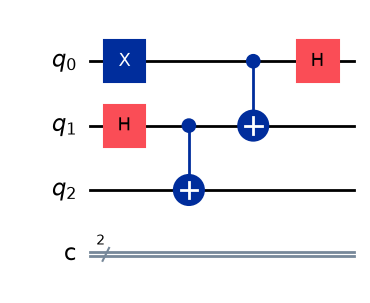

In [32]:
# Alice mixes her unknown state into the Bell pair

qc.cx(0, 1)
qc.h(0)

qc.draw("mpl")

## Why Does the Hadamard Come After the CNOT?

One of the easiest mistakes is to think the Hadamard should come first.

It should **not**.

The protocol works because:

1. The CNOT correlates Alice's unknown qubit with her Bell qubit.
2. The Hadamard then changes Alice's measurement basis.

After these two gates, Alice's two measurements contain exactly the two classical bits Bob will need to recover the original quantum state.

Think of it as:

Unknown State

↓

CNOT (combine information)

↓

Hadamard (change measurement basis)

↓

Measure

↓

Send two classical bits to Bob

### Notes

A question I originally had while learning was:

> Why not apply the Hadamard before the CNOT?

The answer is that the protocol depends on the CNOT first correlating Alice's unknown state with the Bell pair.

Only after this correlation has been created do we apply the Hadamard to place Alice's qubit into the correct measurement basis.

Changing the order would produce a different quantum circuit and would not perform standard quantum teleportation.

# 7. Alice Measures Her Qubits

After Alice applies

```python
qc.cx(0,1)
qc.h(0)
```

she measures **only her two qubits**:

```python
qc.measure(0,0)
qc.measure(1,1)
```

Notice that Bob's qubit (**q2**) is **not measured**.

Alice's measurements produce **two classical bits** that are sent to Bob.

These two bits tell Bob which correction he must apply to recover the original quantum state.

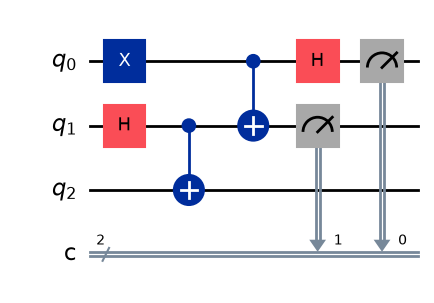

In [33]:
# Alice measures her two qubits

qc.measure(0, 0)
qc.measure(1, 1)

qc.draw("mpl")

## Why Don't We Use `measure_all()`?

A common question is:

> Why not simply use

```python
qc.measure_all()
```

The answer is:

Bob's qubit already contains the teleported quantum state.

If Bob measured his qubit immediately, the quantum state would collapse before he had the opportunity to apply the required correction.

Instead:

1. Alice measures **q0** and **q1**.
2. Alice sends **two classical bits** to Bob.
3. Bob performs the appropriate correction.
4. Bob may then measure his own qubit.

By delaying Bob's measurement, the teleported quantum state is preserved until it has been correctly decoded.

### Notes

One of the biggest "aha!" moments while learning quantum teleportation was realizing that **Bob does not receive a qubit from Alice.**

Instead, Bob receives:

- an already entangled qubit (q2)
- two classical bits from Alice

Using those two classical bits, Bob knows which quantum correction to apply.

The original quantum state is never copied.

Instead, it is transferred from Alice's qubit to Bob's qubit.

This is why quantum teleportation does **not** violate the No-Cloning Theorem.

# 8. Bob Recovers the Quantum State

After receiving Alice's **two classical bits**, Bob knows exactly which quantum correction to apply.

Depending on Alice's measurement results, Bob performs one of four possible operations.

| Alice's Classical Bits | Bob's Operation |
|-------------------------|-----------------|
| 00 | Do Nothing |
| 01 | X |
| 10 | Z |
| 11 | Z then X |

After applying the appropriate correction, Bob's qubit becomes an exact copy of Alice's original quantum state.

Alice's original qubit no longer contains the state because it was destroyed during measurement.

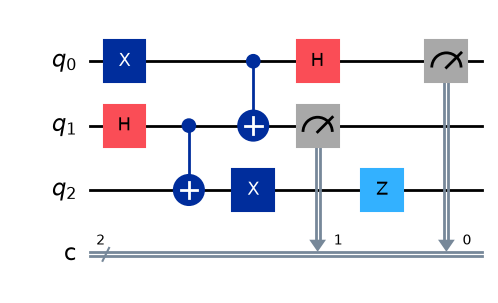

In [34]:
# Bob's corrections
# (Classically controlled in a real teleportation circuit)

# If Alice measured q1 = 1
qc.x(2)

# If Alice measured q0 = 1
qc.z(2)

qc.draw("mpl")

## Why Are Two Classical Bits Needed?

Alice measures **two qubits**.

Each measurement produces one classical bit.

Therefore, Alice sends **two classical bits** to Bob.

Those two bits identify one of four possible correction operations:

- Nothing
- X
- Z
- ZX

This is why one classical bit is **not enough**.

Two bits are required to tell Bob exactly how to recover the original quantum state.

### Notes

One of the biggest insights while learning quantum teleportation was realizing that:

- Alice never sends her qubit to Bob.
- Bob never receives a quantum particle from Alice.
- Bob only receives **two classical bits**.

The quantum information is transferred because Alice and Bob **already shared an entangled Bell pair** before the protocol began.

Without entanglement, teleportation would be impossible.

Without the two classical bits, Bob would not know which correction to apply.

Quantum teleportation therefore requires **both quantum entanglement and classical communication**.

# Notebook Summary

Congratulations! You have completed the Entanglement, Bell States, and Quantum Teleportation notebook.

## Concepts Learned

✅ Multi-Qubit Systems

✅ Tensor Products

✅ CNOT Gate

✅ Bell States

✅ Quantum Entanglement

✅ Bell State Measurements

✅ Quantum Teleportation

✅ Classical Communication

✅ No-Cloning Theorem


## Key Ideas

- Superposition alone does **not** create entanglement.
- A Bell State is created using a **Hadamard gate** followed by a **CNOT gate**.
- Entangled qubits behave as a single quantum system.
- Measuring one qubit of a Bell State determines the outcome of the other.
- Quantum teleportation transfers a **quantum state**, not matter.
- Teleportation requires:
  - An unknown quantum state
  - A shared Bell pair
  - Two classical bits
- The original quantum state is destroyed during measurement, preserving the No-Cloning Theorem.

## Looking Ahead

The next notebook introduces our first quantum search algorithm:

**Grover's Algorithm**

We'll learn how quantum interference allows a quantum computer to search an unsorted database in approximately

$$
O(\sqrt{N})
$$

operations instead of the classical

$$
O(N).
$$

# Quick Self-Review

Try answering these questions without looking back.

1. What is a tensor product?

2. What does the CNOT gate do?

3. Does a CNOT gate by itself create entanglement?

4. How is a Bell State created?

5. What are the possible measurement outcomes of the Bell State?

6. Why are Bell States entangled?

7. Why does quantum teleportation require three qubits?

8. Why is the Bell pair created before Alice's unknown qubit is mixed into the circuit?

9. Why doesn't Alice use `measure_all()`?

10. Why are two classical bits sent to Bob?

11. Why doesn't quantum teleportation violate the No-Cloning Theorem?

If you can confidently answer these questions, you're ready to study quantum algorithms.

# Key Takeaways

- Multi-qubit systems are described using tensor products.
- The CNOT gate is the fundamental two-qubit gate.
- Bell States are the simplest example of quantum entanglement.
- Entanglement creates correlations that cannot be explained classically.
- Quantum teleportation transfers quantum information without sending the physical qubit.
- Classical communication is an essential part of the teleportation protocol.
- Entanglement and classical information work together to transfer quantum states.

Everything in this notebook prepares us for the first true quantum algorithms introduced in the next chapter.